# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [ ]:
expectations_text = """
1) При очень маленьком lr, обучение будет идти очень медленно. Loss скорее всего будет монотонно снижаться без резких скачков, но за разумное количество эпох модель не успеет нормально обучиться. Точность тоже будет расти, но недостаточно быстро.

2) При слишком большом шаге, модель будет перелетать через минимум и не сможет нормально сойтись. На графике это должно выглядеть как скачки loss туда-сюда, точность тоже может дёргаться. В худшем случае loss вообще начнёт расходиться.

3) SGD без momentum на мой взгляд будет самым чувствительным к выбору lr — если не угадать со значением, результат будет плохим. SGD с momentum должен сходиться быстрее и ровнее, так как инерция помогает не застревать в локальных минимумах. Adam, должен вести себя стабильнее всех, потому что адаптирует шаг автоматически, хотя возможно будет склонен к переобучению на поздних эпохах.
"""
print(expectations_text)


1) При очень маленьком lr, обучение будет идти очень медленно. Loss скорее всего будет монотонно снижаться без резких скачков, но за разумное количество эпох модель не успеет нормально обучиться. Точность тоже будет расти, но недостаточно быстро.

2) При слишком большом шаге, модель будет перелетать через минимум и не сможет нормально сойтись. На графике это должно выглядеть как скачки loss туда-сюда, точность тоже может дёргаться. В худшем случае loss вообще начнёт расходиться.

3) SGD без momentum на мой взгляд будет самым чувствительным к выбору lr — если не угадать со значением, результат будет плохим. SGD с momentum должен сходиться быстрее и ровнее, так как инерция помогает не застревать в локальных минимумах. Adam, должен вести себя стабильнее всех, потому что адаптирует шаг автоматически, хотя возможно будет склонен к переобучению на поздних эпохах.



## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device) #Поменял цп на гп, в дальнейших лабораторных будет другое устройство
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [ ]:
batch_size = 64  # 64 хороший вариант и не слишком большой (памяти хватает) и не маленький (обучение адекватное по скорости)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

train size = 60000
test size  = 10000
batch_size = 64


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [ ]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [ ]:
num_epochs = 10  # 10 эпох — кривые успевают устаканиться, но не слишком долго

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. RMSprop — ещё один адаптивный оптимизатор, интересно сравнить с Adam
h_rms = run_experiment(
    config_name="RMSprop lr=0.001",
    optimizer_class=torch.optim.RMSprop,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_rms)
labels.append("RMSprop 0.001")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/10 | train_loss=2.1537, train_acc=0.2968, test_loss=1.9454, test_acc=0.5684
Эпоха 2/10 | train_loss=1.6041, train_acc=0.6813, test_loss=1.2059, test_acc=0.7661
Эпоха 3/10 | train_loss=0.9598, train_acc=0.7934, test_loss=0.7492, test_acc=0.8287
Эпоха 4/10 | train_loss=0.6668, train_acc=0.8379, test_loss=0.5714, test_acc=0.8590
Эпоха 5/10 | train_loss=0.5399, train_acc=0.8622, test_loss=0.4833, test_acc=0.8748
Эпоха 6/10 | train_loss=0.4706, train_acc=0.8756, test_loss=0.4300, test_acc=0.8870
Эпоха 7/10 | train_loss=0.4271, train_acc=0.8840, test_loss=0.3946, test_acc=0.8922
Эпоха 8/10 | train_loss=0.3970, train_acc=0.8902, test_loss=0.3692, test_acc=0.8987
Эпоха 9/10 | train_loss=0.3747, train_acc=0.8956, test_loss=0.3503, test_acc=0.9016
Эпоха 10/10 | train_loss=0.3574, train_acc=0.8997, test_loss=0.3357, test_acc=0.9054

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/10 | train_loss=0.7722, train_acc=0.8033, test_loss=0.3387, test_acc=0.9031
Эпох

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


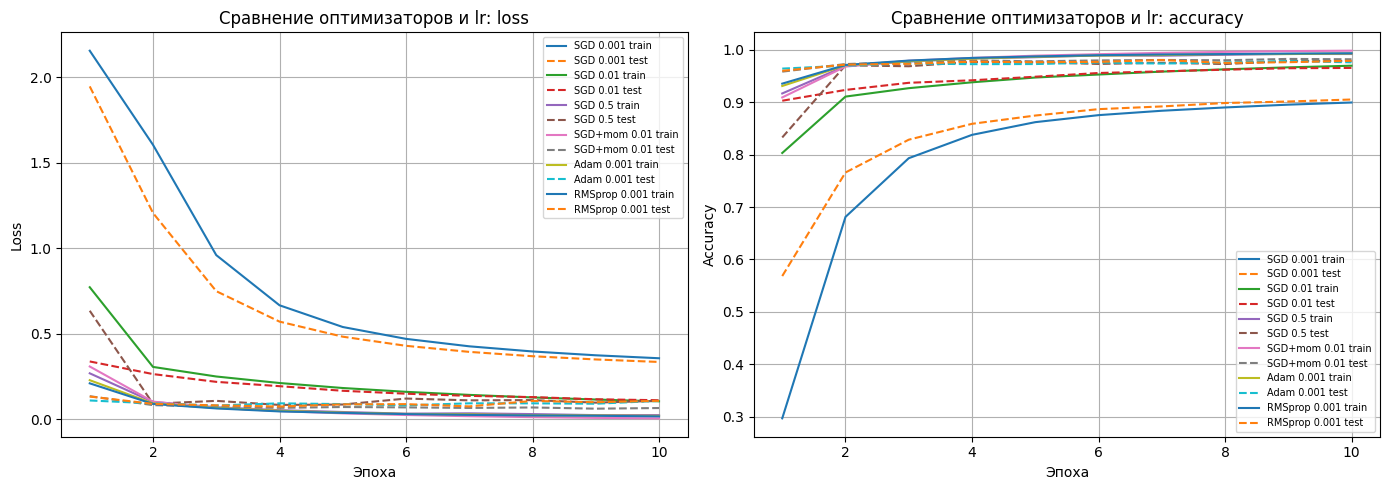

In [ ]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend(fontsize=7)

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [1]:
analysis_text = """
SGD lr=0.001: Самое медленное из всех. На первой эпохе точность была всего 0.5684 — модель почти не обучена. К 10-й эпохе дошло до 0.9054, но кривая явно ещё не вышла на плато — если бы было 15-20 эпох, продолжала бы расти. Loss снижался плавно и монотонно, без единого скачка. Стабильно, но слишком медленно.

SGD lr=0.5: Интересный случай. На первой эпохе train_loss=0.2694, но test_loss=0.6347 — то есть на обучающей выборке уже неплохо, а на тестовой ещё нет. Со 2-й эпохи точность подтянулась до 0.97, но test_loss начал прыгать: 0.0918 → 0.1085 → 0.0848 → 0.0871 → 0.1219 — нет нормальной тенденции к снижению. Итоговая test_acc=0.9789 высокая, но такое поведение loss говорит о нестабильности.

SGD lr=0.01: Хороший баланс. Уже на 1-й эпохе test_acc=0.9031, и дальше всё растёт равномерно. К 10-й эпохе 0.9657. И train, и test loss снижались синхронно, без расхождения — переобучения нет. Самый предсказуемый из всех.

SGD+momentum lr=0.01: Лучший результат по test_acc — 0.9822. Уже на 1-й эпохе 0.9586, это сильно быстрее, чем чистый SGD с тем же lr. Но начиная с эпохи 6-7, train_loss ушёл очень низко (0.0064 к концу), а test_loss держится около 0.063-0.070 и не снижается. Небольшое переобучение есть, но на финальной точности это не сильно сказалось.

Adam lr=0.001: Быстрый старт — 0.9644 уже на первой эпохе. Но test_loss вёл себя странно: упал до 0.0814 на 3-й эпохе, а потом начал расти обратно — к 10-й эпохе уже 0.1084. При этом train_loss продолжал снижаться. Это классический признак переобучения. Итоговая test_acc=0.9764 — хорошая, но ниже, чем у SGD+momentum.

RMSprop lr=0.001: Вёл себя очень похоже на Adam. Старт чуть скромнее (0.9602 на 1-й эпохе), итоговая test_acc=0.9793. Test_loss тоже начал расти на поздних эпохах — та же история с переобучением. В целом Adam и RMSprop дали почти одинаковый результат.
"""
print(analysis_text)


SGD lr=0.001: Самое медленное из всех. На первой эпохе точность была всего 0.5684 — модель почти не обучена. К 10-й эпохе дошло до 0.9054, но кривая явно ещё не вышла на плато — если бы было 15-20 эпох, продолжала бы расти. Loss снижался плавно и монотонно, без единого скачка. Стабильно, но слишком медленно.

SGD lr=0.5: Интересный случай. На первой эпохе train_loss=0.2694, но test_loss=0.6347 — то есть на обучающей выборке уже неплохо, а на тестовой ещё нет. Со 2-й эпохи точность подтянулась до 0.97, но test_loss начал прыгать: 0.0918 → 0.1085 → 0.0848 → 0.0871 → 0.1219 — нет нормальной тенденции к снижению. Итоговая test_acc=0.9789 высокая, но такое поведение loss говорит о нестабильности.

SGD lr=0.01: Хороший баланс. Уже на 1-й эпохе test_acc=0.9031, и дальше всё растёт равномерно. К 10-й эпохе 0.9657. И train, и test loss снижались синхронно, без расхождения — переобучения нет. Самый предсказуемый из всех.

SGD+momentum lr=0.01: Лучший результат по test_acc — 0.9822. Уже на 1-й э

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [ ]:
final_conclusion = """
По SGD: шаг 0.001 — слишком мало, за 10 эпох модель дошла только до 0.905 и явно не насытилась. Шаг 0.01 — нормальный рабочий вариант, стабильный и без сюрпризов, итог 0.966. Шаг 0.5 — уже перебор, test_loss начинает прыгать и непонятно чего ожидать на следующей эпохе.

Momentum реально помогает: с теми же параметрами lr=0.01 добавление momentum=0.9 подняло финальную точность с 0.966 до 0.982 и сходимость стала намного быстрее. Если использую SGD — буду добавлять momentum почти всегда.

Adam удобен для быстрого старта — уже на первой эпохе выдал 0.964. Но на этой задаче он начал переобучаться после 3-й эпохи, test_loss пополз вверх. RMSprop повёл себя почти так же. Если бы было больше эпох — Adam, скорее всего, проиграл бы SGD+momentum по итоговому качеству.

Вывод: для MNIST с таким количеством эпох лучше всего показал себя SGD+momentum. Adam — хороший выбор если нужен быстрый результат и мало эпох, но за стабильностью лучше идти к SGD+momentum.
"""
print(final_conclusion)


По SGD: шаг 0.001 — слишком мало, за 10 эпох модель дошла только до 0.905 и явно не насытилась. Шаг 0.01 — нормальный рабочий вариант, стабильный и без сюрпризов, итог 0.966. Шаг 0.5 — уже перебор, test_loss начинает прыгать и непонятно чего ожидать на следующей эпохе.

Momentum реально помогает: с теми же параметрами lr=0.01 добавление momentum=0.9 подняло финальную точность с 0.966 до 0.982 и сходимость стала намного быстрее. Если использую SGD — буду добавлять momentum почти всегда.

Adam удобен для быстрого старта — уже на первой эпохе выдал 0.964. Но на этой задаче он начал переобучаться после 3-й эпохи, test_loss пополз вверх. RMSprop повёл себя почти так же. Если бы было больше эпох — Adam, скорее всего, проиграл бы SGD+momentum по итоговому качеству.

Вывод: для MNIST с таким количеством эпох лучше всего показал себя SGD+momentum. Adam — хороший выбор если нужен быстрый результат и мало эпох, но за стабильностью лучше идти к SGD+momentum.

